<a href="https://colab.research.google.com/github/juan-lawrie/Repaso-Ciencias-de-datos/blob/main/Copia_de_09b_%5BTeor%C3%ADa%5D_An%C3%A1lisis_exploratorio_de_dos_conjuntos_de_datos_cuantitativos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📌 Tema 9: Análisis exploratorio de dos conjuntos de datos cuantitativos


❗Antes de comenzar con la clase, hacete una copia de este documento así podés editarlo y guardar los cambios.

Hacé clic acá arriba, donde dice "Copiar en Drive".

Luego seguís trabajando en esa copia y te queda todo guardado en tu Drive.

---

## 🪑 Edad y sedentarismo

En una ciudad con altos índices de obesidad, se le pidió a 30 adolescentes que registraran, durante un mes, la cantidad de horas diarias que dedicaban a actividades sedentarias, como mirar televisión, estudiar o usar la computadora. Al finalizar el mes, cada persona calculó su promedio diario.

Los datos recolectados incluyen:
- **Edad** (en años)
- **Horas** promedio por día dedicadas a actividades sedentarias

Estos valores se organizaron en el siguiente diccionario:

In [ ]:
datos_sedentarismo = {
    "edad": [
        11.2, 11.4, 11.4, 11.5, 11.6, 11.7, 11.9, 12.6, 12.8, 13.2,
        13.8, 13.8, 14.0, 14.3, 14.5, 14.6, 15.0, 15.4, 15.6, 15.9,
        16.2, 16.5, 17.0, 17.3, 17.4, 17.5, 17.8, 17.9, 18.2, 18.3
    ],
    "horas": [
        5.5, 5.4, 4.5, 4.8, 5.0, 5.5, 4.3, 5.7, 4.7, 5.4,
        5.6, 5.5, 6.6, 5.5, 5.4, 5.3, 5.2, 7.0, 5.9, 6.6,
        6.3, 5.8, 6.9, 6.9, 6.2, 5.5, 6.0, 6.5, 6.4, 5.7
    ]
}

📌 Preguntas:

1. ¿Estamos trabajando con una población o con una muestra?
2. ¿De qué tipo son los datos con los que contamos?
3. ¿Cuáles son las unidades experimentales?


A modo de exploración inicial de los datos podemos comenzar analizando por separado la  distribución de *Edad* y *Horas*.

Para ello, construiremos un **resumen numérico** que incluya:

- Media
- Desvío estándar
- Mínimo
- Primer cuartil (Q1)
- Mediana (Q2)
- Tercer cuartil (Q3)
- Máximo

Con las funciones de esta celda, vamos a definir una función `resumen_numerico` para obtener estas medidas resumen.



In [ ]:
def calcular_media(lista):
    return sum(lista) / len(lista)

def calcular_desvio(lista):
    media = calcular_media(lista)

    suma_diferencias = 0
    for x in lista:
        dif = x - media
        suma_diferencias += dif ** 2

    desvio = (suma_diferencias / len(lista)) ** (1/2)
    return desvio

def calcular_mediana(lista):
    lista_ordenada = lista.copy()
    lista_ordenada.sort()

    n = len(lista_ordenada)

    if n % 2 == 0:
        mediana = (lista_ordenada[n // 2 - 1] + lista_ordenada[n // 2]) / 2
    else:
        mediana = lista_ordenada[n // 2]

    return mediana

def calcular_cuartiles(lista):
    datos = lista.copy()
    datos.sort()

    n = len(datos)
    if n % 2 == 0:
        mitad_inferior = datos[:n // 2]
        mitad_superior = datos[n // 2:]
    else:
        mitad_inferior = datos[:n // 2]
        mitad_superior = datos[n // 2 + 1:]

    Q1 = calcular_mediana(mitad_inferior)
    Q2 = calcular_mediana(datos)
    Q3 = calcular_mediana(mitad_superior)

    return Q1, Q2, Q3

Completá acá debajo la función `resumen_numerico` para que retorne un diccionario con las medidas resumen que necesitamos:

In [ ]:
def resumen_numerico(lista):
    Q1, Q2, Q3 = ...
    return {
        "media": ...
        "desvío": ...
        "mínimo": min(...),
        "Q1": ...
        "Q2": ...
        "Q3": ...
        "máximo": ...
    }

Luego usá la función `resumen_numerico` con los datos de edad y horas, y mostrá los resultados  redondeando a dos decimales:

In [ ]:
resumen_edad = ...
resumen_horas = ...

print("Resumen Edad:")
for medida, valor in resumen_edad.items():
    print(medida + ":", round(..., ...))

print() # línea en blanco, funciona como espacio

print("Resumen Horas:")
for medida, valor in ...:
    print(medida + ":", round(..., ...))

📌 Preguntas:
1. ¿Entre qué valores se distribuyen las edades? ¿Y las horas?
2. ¿Cuál es la dispersión de las edades alrededor de la media? ¿Y de las horas?
3. ¿Cuál es la dispersión del 50% central de las edades? ¿Y de las horas?
4. ¿Qué sugiere la relación entre media y mediana? ¿Hay indicios de asimetría?

Ahora complementemos el análisis haciendo un **resumen gráfico** con un boxplot para cada conjunto de datos:

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.boxplot(..., vert=False)
plt.title("Boxplot de Edad")
plt.xlabel("Edad (años)")
plt.show()

In [ ]:
plt.figure()
plt.boxplot(..., vert=False)
plt.title("Boxplot de Horas")
plt.xlabel("Horas")
plt.show()

📌 Preguntas:

1. ¿Cómo es la distribución de las edades? ¿Y la distribución de las horas?
2. ¿Notás alguna asimetría en las distribuciones?
3. ¿Hay valores atípicos?

Hasta acá hicimos un análisis exploratorio de cada conjunto por separado.

Ahora nos preguntamos 🤔:
- **¿Habrá alguna relación entre la cantidad de horas dedicadas a actividades sedentarias y la edad?**
- **¿Los adolescentes más chicos le dedicarán mayor o menor cantidad de horas que los más grandes a ese tipo de actividades?**


En este caso, se trata de **relacionar los valores de dos conjuntos de datos**
(horas y edad).

Para empezar, veamos qué gráfico podemos utilizar para describir esta relación.

Mirá el código que sigue y analizá cada linea antes de ejecutarlo:

In [ ]:
plt.figure()
plt.scatter(datos_sedentarismo["edad"], datos_sedentarismo["horas"], alpha=0.7)
plt.title("Relación entre edad y horas de actividad sedentaria")
plt.xlabel("Edad (años)")
plt.ylabel("Horas")
plt.show()

📌 Preguntas:

1. ¿Qué muestra cada eje del gráfico? ¿Qué representa cada punto?
2. Si mirás el gráfico de izquierda a derecha (de menor a mayor edad), ¿notás algún patrón o tendencia general?
3. ¿A qué valores de horas se asocian las edades más bajas? ¿Y las edades más altas?

---

### 🔄 Relación entre dos conjuntos de datos

En este ejemplo, estamos analizando la **relación** entre dos conjuntos diferentes de **datos cuantitativos**:
- Los datos correspondientes a la **edad** de la persona.
- Los datos correspondientes a la cantidad de **horas** diarias dedicadas a actividades sedentarias.





### 📈 Diagrama de dispersión


Para representar gráficamente la relación entre datos cuantitativos, podemos utilizar un **diagrama de dispersión** (*scatter plot*, en inglés).

En este tipo de gráfico, un eje muestra uno de los conjuntos y el otro eje muestra el segundo.

En nuestro caso, los valores de edad se ubican sobre el **eje horizontal**, y los de horas, sobre **el eje vertical**.

Cada **punto** representa los datos correspondientes a una **unidad experimental**, combinando un valor de cada conjunto.

👀 **¿Qué observamos en un diagrama de dispersión?**

- **Tipo de relación entre los datos:**

 ¿Existe una tendencia creciente (los puntos suben de izquierda a derecha) o decreciente (los puntos bajan)?

 ¿La relación sigue una línea recta, una curva o no muestra un patrón claro?

- **Valores atípicos:**

 ¿Hay puntos que se alejan del patrón general?

- **Agrupamientos o patrones:**

 ¿Algunos puntos forman grupos o se concentran más en ciertas zonas del gráfico?

---

🧠 Preguntas:

1. ¿Nos sirven los análisis individuales de edad y horas para responder las dos preguntas iniciales? Recordá que nos preguntamos:
    - ¿Habrá alguna relación entre la cantidad de horas dedicadas a actividades sedentarias y la edad?
    - ¿Los adolescentes más chicos le dedicarán mayor o menor cantidad de horas que los más grandes a ese tipo de actividades?
2. ¿Qué aporta el diagrama de dispersión que no se podía ver en los análisis por separado de edad y horas?
3. En el diagrama de dispersión de edad y horas:
    - ¿Los puntos tienden a subir, bajar o no seguir una dirección clara?
    - ¿Notás algún cambio en la tendencia a medida que aumenta la edad?
4. Elegí un punto del diagrama de dispersión, por ejemplo (11.2, 5.5), y ubicalo en el diccionario `datos_sedentarismo`? Usando indexación, accedé a esos datos en las listas `"edad" `y `"horas"`?
5. ¿Qué representa cada índice en las listas del diccionario `datos_sedentarismo`?

✏️ Respuestas:

1. ...
2. ...
3. ...
4. ...
5. ...

---

## 🏃 Entrenamiento y desempeño en carrera

Ahora contamos con datos de un estudio hecho con **14 atletas** sobre la relación entre el **grado de entrenamiento** y el **desempeño posterior en una carrera de 10 km**.

El grado de entrenamiento se midió mediante la **“Potencia aeróbica máxima”** (ml/(kg min) alcanzada y el desempeño posterior mediante el **tiempo** (min) empleado en completar 10 km durante una competencia.

Los datos recopilados son los siguientes:

In [ ]:
datos_entrenamiento = {
    "potencia": [
        47.170, 47.410, 47.880, 51.050, 51.320, 52.180, 52.360,
        52.830, 53.310, 53.930, 55.290, 57.910, 57.940, 61.320
    ],
    "tiempo":[
        47.830, 46.030, 45.600, 48.550, 42.370, 43.930, 44.900,
        40.030, 42.030, 45.120, 39.800, 44.900, 41.320, 39.370
    ]
}

A modo exploratorio, queremos hacer un diagrama de dispersión para estudiar la relación entre estas cantidades.

Sin embargo, el código que tenemos no parece funcionar bien. ¿Te animás a corregirlo? 🤓

In [ ]:
plt.figure()
plt.scater(datos_entrenamiento["potencia "], datos_entrenamiento, alpha=0.7)
plt.title("Relación entre potencia aeróbica máxima y tiempo de carrera")
plt.xlabel("Potencia aeróbica máxima")
plt.ylabel("Tiempo de carrera")
plt.show()

📌 Preguntas:

1. ¿Qué muestra cada eje del gráfico? ¿Qué representa cada punto?
2. ¿Qué sucede con el tiempo a medida que aumenta la potencia aeróbica máxima alcanzada?

---

### 💻 Gráfico de dispersión con Matplotlib

Para hacer el gráfico de dispersión usamos la función `plt.scatter`:

```python
plt.scatter(datos_entrenamiento["potencia"], datos_entrenamiento["tiempo"], alpha=0.7)
```
A esta función le pasamos los datos de cada conjunto por separado y en orden.
- `datos_entrenamiento["potencia"]` son los datos que se grafican en el **eje horizontal** (X).
- `datos_entrenamiento["tiempo"]` son los datos que se grafican en el **eje vertical** (Y).

Luego, podemos personalizar los puntos del gráfico, como el **tamaño**, la **forma**, el **color** y la **opacidad**.

En nuestro caso, usamos el parámetro `alpha=0.7` que indica que los puntos tendrán un **70% de opacidad** (o, lo que es lo mismo, un 30% de transparencia), lo cual es útil cuando hay puntos superpuestos, ya que permite ver mejor las concentraciones de datos.

---

🧠 Preguntas:

1. Probá cambiar los límites de los ejes con `plt.xlim()` y `plt.ylim()`. ¿Qué notás?
2. Explorá cómo personalizar el gráfico de dispersión con estos parámetros:
    - `s`: tamaño de los puntos (por ejemplo, `s=50`)
    - `c`: color de los puntos (por ejemplo, `c="red"`)
    - `marker`: forma del punto (por ejemplo, `"o"`, `"x"`, `"s"`, etc.)
3. Probá distintos valores de `alpha` (transparencia). ¿Qué sucede al usar valores bajos como `alpha=0.1` o altos como `alpha=1.0`?
4. ¿Qué pasa si se invierte el orden de los datos en `plt.scatter()`? ¿Qué eje representa qué?
5. ¿Qué pasa si uno de los conjuntos de datos tiene un valor muy extremo (*outlier*)?

✏️ Respuestas:

1. ...
2. ...
3. ...
4. ...
5. ...

---

## 📈 ¿Existe una relación lineal?

En general, un diagrama de dispersión nos permite ver la **forma**, la **dirección** y lel **grado de la asociación** entre datos cuantitativos.

Cuando los puntos se alinean de a lo largo de una **línea recta**, podemos decir que existe una **relación lineal fuerte** entre ellos.

🔍 Sin embargo, como vemos en la figura, **la percepción visual puede engañarnos**, ya que la forma en que elegimos la **escala de los ejes** puede cambiar cómo se ven los puntos, y hacernos pensar que hay (o no hay) una relación que en realidad es débil o inexistente.

<center>
<div style="display: flex; justify-content: space-between;"> <img src="https://drive.google.com/uc?id=1BB5Zl5L5NzYex7_4C7EyQgk7uK_JOVTN" width="700" />
</center>

En esta figura vemos como en el diagrama de dispersión de la izquierda parece haber una relación lineal más fuerte que en el de la derecha.

Por eso, necesitamos algo más objetivo: un **número** que mida la fuerza y dirección de esa relación, sin importar la escala ni las unidades.

Este número ideal debe cumplir con ciertas **propiedades** importantes:
- 📈 Ser **positivo** si ambos conjuntos de datos tienden a **aumentar juntos**.
- 📉 Ser **negativo** si uno aumenta mientras el otro **disminuye**.
- 📏 Tener un valor más **cercano a 1 o -1** cuanto más próximos estén los puntos a una línea recta.
- 🧮 **No depender de las unidades** en las que estén expresados los datos.

Para construir este número, retomemos los datos de **edad** y **horas dedicadas a actividades sedentarias** en 30 adolescentes.

Fijate el código en las celdas que siguen y tratá de entenderlo antes de ejecutarlo:

In [ ]:
def calcular_correlacion(x, y):
    # Total de datos
    n = len(x)

    # Medias
    media_x = sum(x) / n
    media_y = sum(y) / n

    # Sumas para covarianza y desvíos
    suma_cov = 0
    suma_dif_cuad_x = 0
    suma_dif_cuad_y = 0

    for i in range(n):
        dx = x[i] - media_x
        dy = y[i] - media_y

        suma_cov += dx * dy
        suma_dif_cuad_x += dx ** 2
        suma_dif_cuad_y += dy ** 2

    cov = suma_cov / n
    desvio_x = (suma_dif_cuad_x / n) ** 0.5
    desvio_y = (suma_dif_cuad_y / n) ** 0.5

    # Correlación
    correlacion = cov / (desvio_x * desvio_y)

    return correlacion

In [ ]:
corr_edad_horas = calcular_correlacion(datos_sedentarismo["edad"], datos_sedentarismo["horas"])
print("Coeficiente de correlación (edad vs horas sedentarias):", round(corr_edad_horas, 2))

📌 Preguntas:

1. ¿Cuántos parámetros recibe la función y qué representa cada uno?
2. ¿Cómo interpretarías el valor obtenido? ¿En qué casos esperarías que sea negativo?
3. En esta línea: `correlacion = cov / (desvio_x * desvio_y)` ¿de qué depende que el resultado sea positivo o negativo?

---

### 🔗 Coeficiente de correlación

El ejemplo que vimos implementamos el **coeficiente de correlación**, también llamado *coeficiente de correlación de Pearson*.

Este coeficiente es un **número que mide la intensidad y dirección de la relación lineal entre dos conjuntos de datos cuantitativos**.


En el ejemplo, tenemos datos de:
- La edad de varias personas
- Las horas que estudian esas personas

En este caso, buscamos entender si a mayor edad, las personas estudian más o menos horas, y qué tan fuerte es esa relación.

El **coeficiente de correlación se suele denotar con la letra $r$** cuando calculamos con datos de una muestra.

Supongamos que tenemos dos conjuntos de datos:

$$
X = (x_1, x_2, \ldots, x_n) \quad\text{y}\quad Y = (y_1, y_2, \ldots, y_n)
$$

Cada par $(x_i, y_i)$ es una pareja de datos relacionados, por ejemplo, la **edad** y las **horas** de estudio de la persona número $i$.


La fórmula del coeficiente de correlación es:

$$
r = \frac{\text{cov}(X,Y)}{s_X s_Y}
$$

donde:

* $\text{cov}(X,Y)$ es la **covarianza** entre $X$ y $Y$.
* $s_X$ es la **desviación estándar** de $X$.
* $s_Y$ es la **desviación estándar** de $Y$.

🔗 **¿Qué es la covarianza?**

La **covarianza** es un número que nos dice el **grado de variación conjunta** de dos conjuntos de datos (si suben y bajan juntos o no).

Se calcula así:

$$
\text{cov}(X,Y) = \frac{1}{n} \sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})
$$

Acá:
- $\bar{x}$ es la media de los datos de $X$.
- $\bar{y}$ es la media de los datos de $Y$.

Interpretación de la covarianza:
- Si es **positiva**, cuando $X$ sube, $Y$ también sube.
- Si es **negativa**, cuando $X$ sube, $Y$ baja.
- Si es **cero o casi cero**, no hay una relación clara.

🤔 **¿Por qué usamos el coeficiente de correlación y no la covarianza directamente?**

La covarianza depende de las unidades de medida (por ejemplo, años, horas, etc.) y puede ser difícil de interpretar.

Por eso, dividimos la covarianza por las desviaciones estándar, para **normalizarla** y obtener un número entre -1 y 1, sin importar las unidades.

Esto hace que $r$ sea mucho más fácil de comparar y entender.

Interpretación del **valor** de $r$:
- Si $r$ está **cerca de 1**, hay una relación lineal positiva fuerte (ambos conjuntos suben juntos).
- Si $r$ está **cerca de -1**, hay una relación lineal negativa fuerte (uno sube y el otro baja).
- Si $r$ está **cerca de 0**, no hay relación lineal clara.

La dirección de la relación está indicada por el **signo** de $r$:
- Si es **positivo** vemos una **relación positiva** (ascendente).
- Si es **negativo** vemos una **relación negativa** (descendente).

Recordemos que la correlación $r$ no tiene unidades y es independiente de la escala de cada variable.

Además, es una medida simétrica, lo que significa que la correlación entre $X$ e $Y$ es la misma que entre $Y$ y $X$.

En la figura vemos cómo los valores de $r$ se alejan del 1
ó -1 a medida que decrece el grado de asociación lineal entre $X$ e $Y$:

<div style="display: flex; justify-content: space-between;"> <img src="https://drive.google.com/uc?id=1Lpn2178IQeMFPH-LORE8i-30sC-UoOu8" width="1000" />




En esta otra figura vemos cómo $r$ es cercano a cero cuando los pares de datos no están asociados
hay una relación no lineal $X$ e $Y$:

<div style="display: flex; justify-content: space-between;"> <img src="https://drive.google.com/uc?id=10VGKk4uSBHy0O1-9pLZehVVL9KFh_kIx" width="1000" />


📌 Un valor de $r$ cercano a 0 indica que no hay **relación lineal**, pero **podría haber otro tipo de relación** entre los datos.

En el ejemplo, obtuvimos $r = 0.68$.
- Primero, como es un número **positivo** y no está cerca de cero, esto nos indica que hay una **relación positiva** entre las variables.
- Además, como el valor está bastante **cerca de 1**, significa que esta relación es **bastante fuerte y cercana a una línea recta**.

En otras palabras, podemos decir que: los adolescentes más jóvenes tienden a pasar menos horas en actividades sedentarias, y a medida que crecen, pasan más horas en esas actividades. Este aumento ocurre de forma bastante constante, casi como si siguiera una línea recta.

---

Mirá este diagrama de dispersión:

<center>
  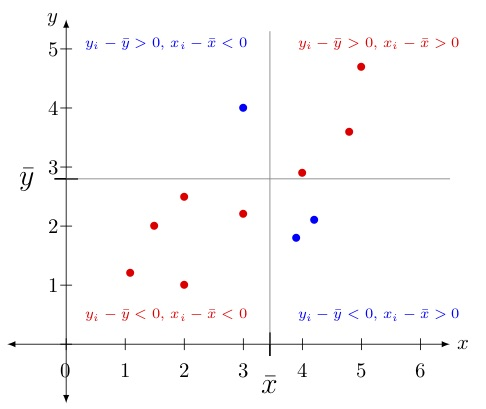
</center>



🧠 Preguntas:

1. ¿Qué representa cada cuadrante en relación a $\bar{x}$ y $\bar{y}$?.
2. ¿En qué cuadrantes el signo del producto $(x_i - \bar{x})(y_i - \bar{y})$ es positivo y en cuáles es negativo?
3. ¿De qué color hay más puntos, rojos o azules? ¿Cómo afecta esto al signo de la covarianza?
4. Repetí el análisis de la pregunta 3 para estos gráficos:

<center>
  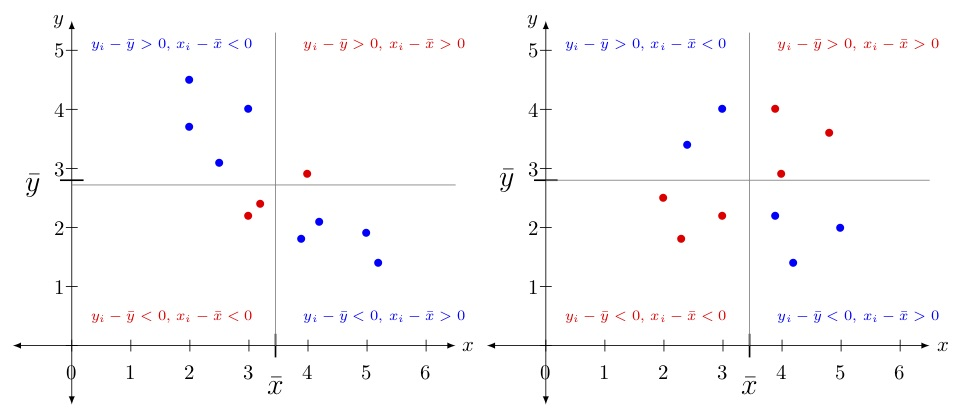
</center>

5. ¿Los siguientes conjuntos de datos tienen la misma covarianza o no? Si no, ¿cuál de ellos te parece que tiene mayor covarianza?

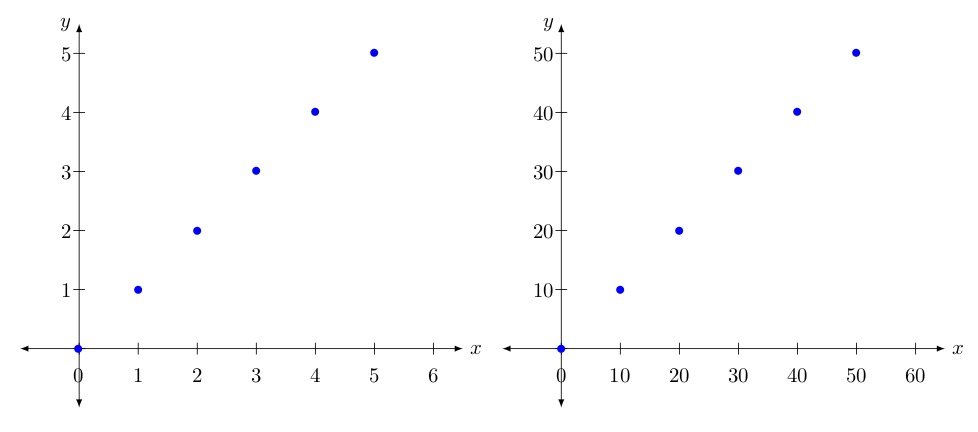

✏️ Respuestas:

1. ...
2. ...
3. ...
4. ...

---

## 📊 Usando el coeficiente de correlación

Vamos a retomar los datos del estudio sobre el **grado de entrenamiento** y el **desempeño en una carrera de 10 km**.

Nuestro objetivo es calcular el **coeficiente de correlación** para analizar si existe una **relación lineal** entre la **potencia aeróbica máxima** y el **tiempo que tarda una persona en completar la carrera**.

Completá el siguiente código para obtener el valor del coeficiente:

In [ ]:
corr_potencia_tiempo = ...
print("Coeficiente de correlación (potencia aerobica vs tiempo de carrera):", round(..., ...))

📌 Preguntas:

1. ¿Qué te dice el signo del coeficiente de correlación $r$?
2. ¿Qué te indica la magnitud del coeficiente?
2. ¿Hay evidencia de una relación lineal entre la potencia aeróbica máxima y el tiempo de carrera?

---

### 💻 Coeficiente de correlación con la compu

Para calcular el coeficiente de correlación en la compu definimos la función:

```python
def calcular_correlacion(x, y):
```

Esta función recibe dos listas del mismo tamaño correspondientes a los datos de $X$ y de $Y$:

Dentro de la función, calculamos la correlación $r$ como el cociente entre la covarianza y el producto de los desvíos de $X$ e $Y$:

$$
r = \frac{\text{cov}(X,Y)}{s_X s_Y}
$$

Para ello, primero calculamos la cantidad de datos $n$ y las medias $\bar{x}$ y $\bar{y}$ de cada lista:

```python
n = len(x)
media_x = sum(x) / n
media_y = sum(y) / n
```
Luego, inicializamos las sumas necesarias para calcular la covarianza y los desvíos.

Recorremos cada par de dato $(x_i,y_i)$ y actualizamos las sumas:

```python
suma_cov = 0
suma_dif_cuad_x = 0
suma_dif_cuad_y = 0

for i in range(n):
    dx = x[i] - media_x
    dy = y[i] - media_y

    suma_cov += dx * dy
    suma_dif_cuad_x += dx ** 2
    suma_dif_cuad_y += dy ** 2

cov = suma_cov / n
desvio_x = (suma_dif_cuad_x / n) ** 0.5
desvio_y = (suma_dif_cuad_y / n) ** 0.5
```



Finalmente, obtenemos la correlación dividiendo la covarianza entre el producto de los desvios:


```python
correlacion = cov / (desvio_x * desvio_y)
```

Recordemos que el resultado estará entre -1 y 1, donde:
- 1 indica una relación positiva perfecta.
- 0 indica que no hay relación lineal.
- -1 indica una relación negativa perfecta.


---

🧠 Preguntas:

1. ¿En qué unidades está la covarianza? Si los datos de una lista están en kilogramos (kg) y los de la otra en metros (m), ¿qué unidades tiene la covarianza? Explicá por qué.
2. ¿En qué unidades está el desvío estándar?
   Si los datos están en kg, ¿en qué unidades se expresa el desvío estándar? ¿Y si están en metros?
3. ¿Por qué el coeficiente de correlación no tiene unidades? Recordá que se define como el cociente entre la covarianza y el producto de los desvíos estándar. ¿Qué ocurre con las unidades en esa división?
4. ¿Qué significa que la correlación sea cercana a 1, a 0 o a -1? ¿Cómo interpretarías los siguientes casos?:
   - $r=0.98$
   - $r=0.01$
   - $r=-0.85$
5. ¿Será sensible el coeficiente de correlación a los valores extremos? Si en una de las listas agregamos un dato muy alejado del resto, ¿cómo afecta al valor de $r$?

✏️ Respuestas:

1. ...
2. ...
3. ...
4. ...
5. ...

---

## 📚 Recursos adicionales

- 📖 En el capítulo 22 de [este libro](http://www.bnm.me.gov.ar/giga1/documentos/EL001858.pdf) encontrarás más información sobre **diagramas de dispersión** y **coeficiente de correlación**.
- 🔗 Mirá más ejemplos de cómo construir **diagrama de dispersión** en [esta página](https://www.geeksforgeeks.org/what-is-a-scatter-plot-in-python/).
- 🔗 Para leer una introducción a **Matplotlib** y sus componentes visitá [este enlace](https://www.geeksforgeeks.org/python-introduction-matplotlib/).